In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
#from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve
)
from xgboost import XGBClassifier

## Oczyszczanie i EDA

In [2]:
# Wczytanie danych
df = pd.read_csv('neo_v2.csv')

In [3]:
# Podstawowy przegląd
print(df.shape)

print()
print("-" * 80)
print()

print(df.info())

print()
print("-" * 80)
print()

print(df.head().round(2))

(90836, 10)

--------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB
None

--------------------------------------------------------------------------------

        id                 name  est_diameter_min

In [4]:
# Usunięcie duplikatów
duplicate = df.duplicated().sum()

if duplicate != 0:
    df.drop_duplicates()
    print("Po usunięciu duplikatów:", df.shape)
else:
    print("Nie znaleziono duplikatów")

Nie znaleziono duplikatów


In [5]:
# Uzupełnienie lub usunięcie brakujących wartości

# Sprawdzenie liczby braków w kolumnach
print(df.isna().sum().sort_values(ascending=False))

# Jeśli kolumna ma dużo braków, można ją usunąć
threshold = 0.3  # np. jeśli >30% wartości brakujących
cols_to_drop = [col for col in df.columns if df[col].isna().mean() > threshold]
df = df.drop(columns=cols_to_drop)
print("Usunięte kolumny z >30% braków:", cols_to_drop)

# Wypełnienie braków w kolumnach liczbowych np. medianą
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isna().any():
        median = df[col].median()
        df[col] = df[col].fillna(median)
        print(f"Wypełniono {col} medianą = {median}")

# Wypełnienie braków w kolumnach kategorii / tekstowych np. wartością 'Unknown'
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna('Unknown')
        print(f"Wypełniono {col} wartością 'Unknown'")

id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64
Usunięte kolumny z >30% braków: []


In [6]:
# Usunięcie lub korekta wartości odstających / niepoprawnych

# Usuwanie wierszy z wartościami < 0
for col in num_cols:
    # jeśli sensowną wartością jest ≥0
    bad_vals = df[df[col] < 0][col]
    if not bad_vals.empty:
        print(f"Kolumna {col} ma {len(bad_vals)} niepoprawnych wartości (<0). Usuwam wiersze.")
        df = df[df[col] >= 0]

# Usunięcie ujemnych wartości bez kolumny id
#num_cols = df.select_dtypes(include=[np.number]).columns
#for col in num_cols:
    #df = df[df[col] >= 0]

In [7]:
# Zmiana nazw kolumn na czytelniejsze i usunięcie spacji
df = df.rename(columns=lambda x: x.strip().lower().replace(' ', '_'))
print("Zmieniono nazwy kolumn")

Zmieniono nazwy kolumn


In [8]:
# Usumięcie kolumny 'id'
df = df.drop(columns=['id'])

In [9]:
# Wyświetlenie statystyk
df.describe().round(2)

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.00,90836.00,90836.00,90836.00,90836.00
mean,0.13,0.28,48066.92,37066546.03,23.53
std,0.30,0.67,25293.30,22352040.60,2.89
min,0.00,0.00,203.35,6745.53,9.23
25%,0.02,0.04,28619.02,17210820.24,21.34
50%,0.05,0.11,44190.12,37846579.26,23.70
75%,0.14,0.32,62923.60,56548996.45,25.70
max,37.89,84.73,236990.13,74798651.45,33.20


In [10]:
# Pobranie kolumn numerycznych
num_cols = df.select_dtypes(include='number').columns

In [11]:
# Korelacje numeryczne
corr = df[num_cols].corr()
print("\nMacierz korelacji:\n", corr.round(2).to_string())


Macierz korelacji:
                     est_diameter_min  est_diameter_max  relative_velocity  miss_distance  absolute_magnitude
est_diameter_min                1.00              1.00               0.22           0.14               -0.56
est_diameter_max                1.00              1.00               0.22           0.14               -0.56
relative_velocity               0.22              0.22               1.00           0.33               -0.35
miss_distance                   0.14              0.14               0.33           1.00               -0.26
absolute_magnitude             -0.56             -0.56              -0.35          -0.26                1.00


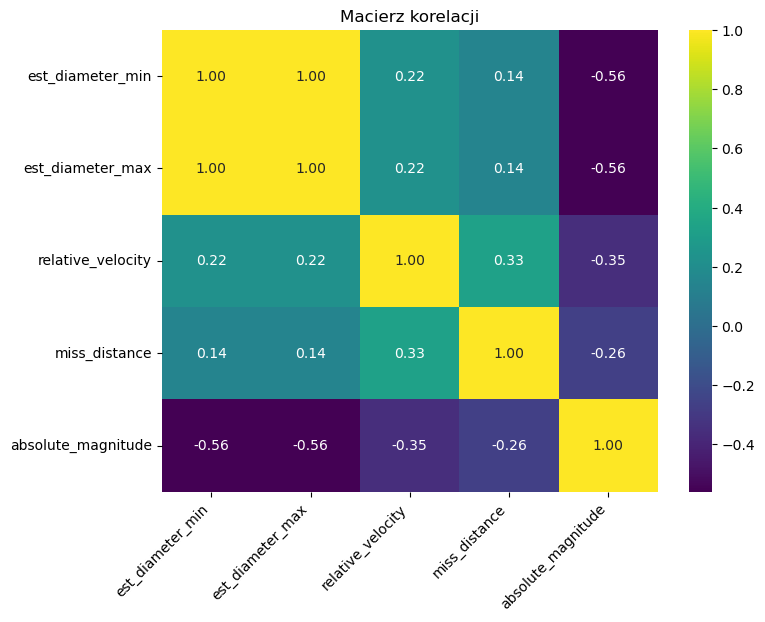

In [12]:
# Zobrazowanie korelacji
plt.figure(figsize=(8, 6))

ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', cbar=True)
#ax = sns.heatmap(corr, annot=True, cmap='viridis', fmt='.4f')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') 
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title(f"Macierz korelacji")
plt.show()

Wniosek:
- est_diameter/absolute_magnitude: to najsilniejsza zależność - duże obiekty są jaśniejsze (im mniejsza magnituda to jaśniejszy obiekt)
- est_diameter/relative_velocity oraz absolute_magnitude/relative_velocity: to zależności umiarkowane - większe/jasne obiekty częściej są szybsze
- relative_velocity/miss_distance: również jest umiarkowana - szybsze obiekty przelatują zwykle dalej
- est_diamete_min/max: to duplikat informacji - duża korelacja = 1

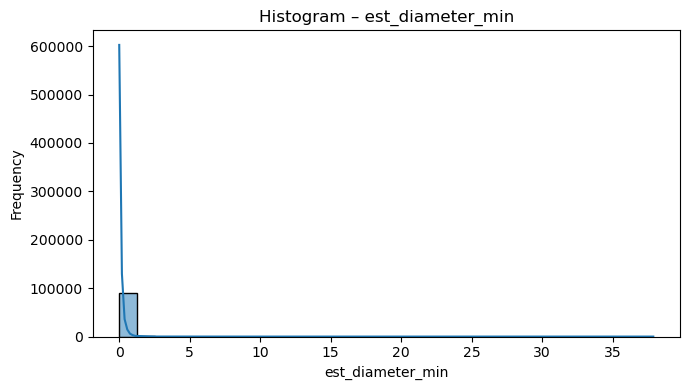

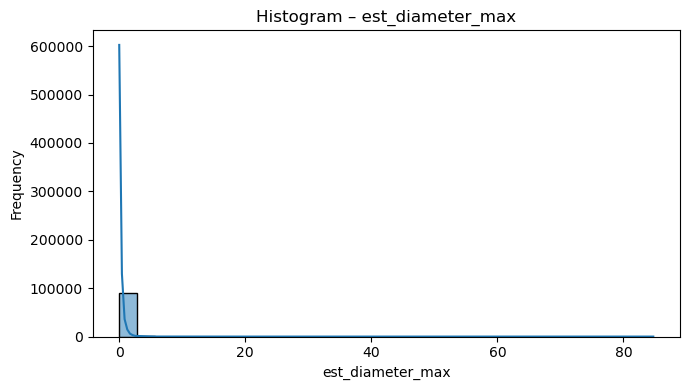

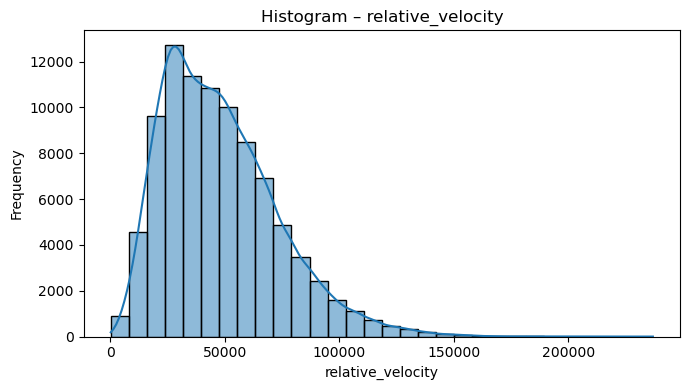

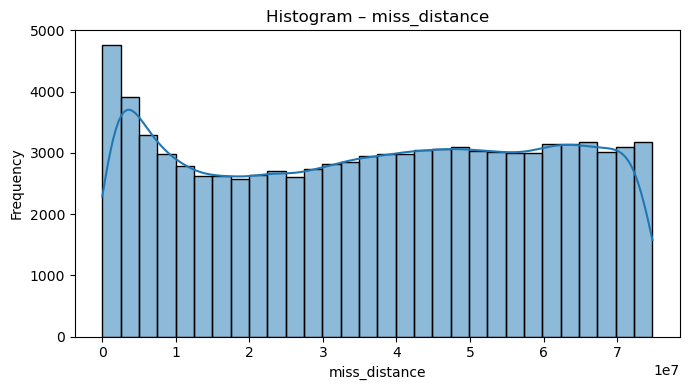

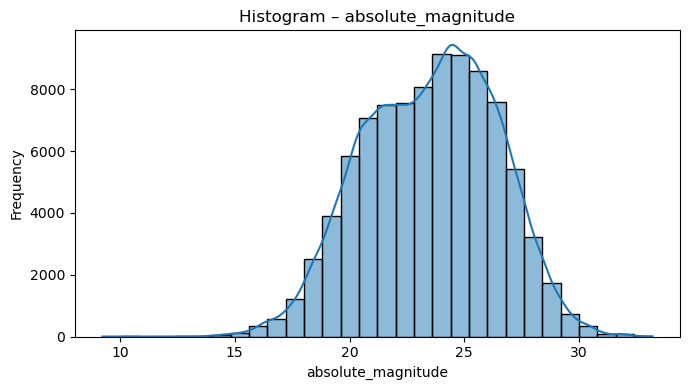

In [13]:
# Histogramy dla kolumn liczbowych
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], bins=30, kde=True)   
    plt.title(f"Histogram – {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

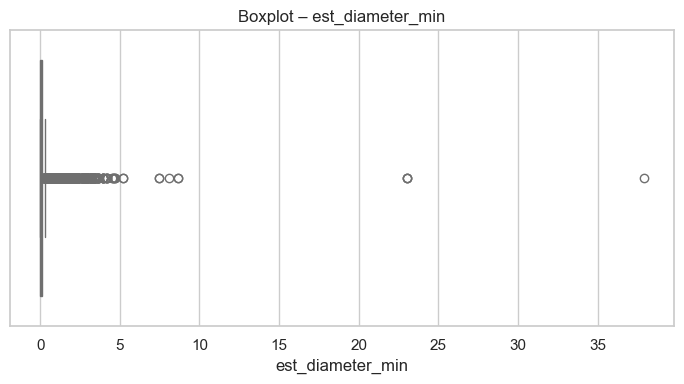

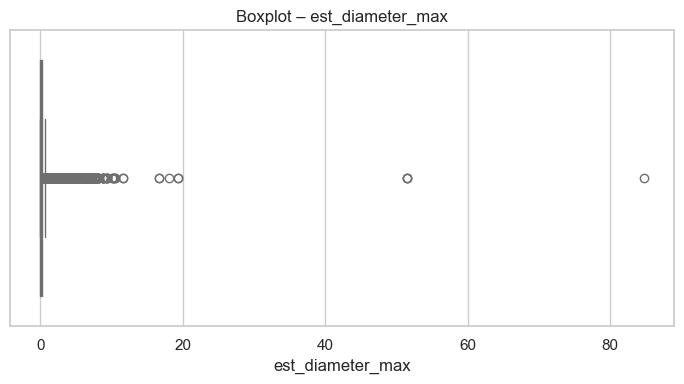

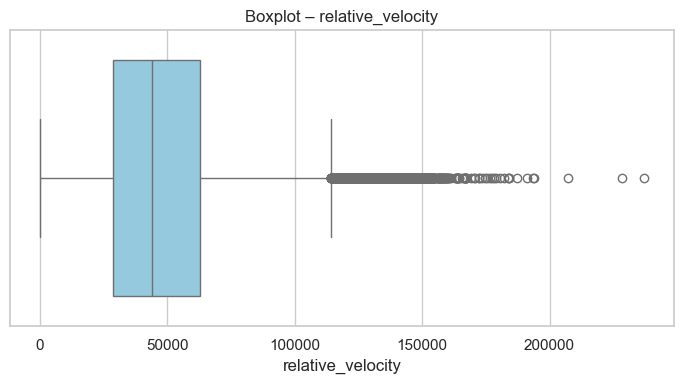

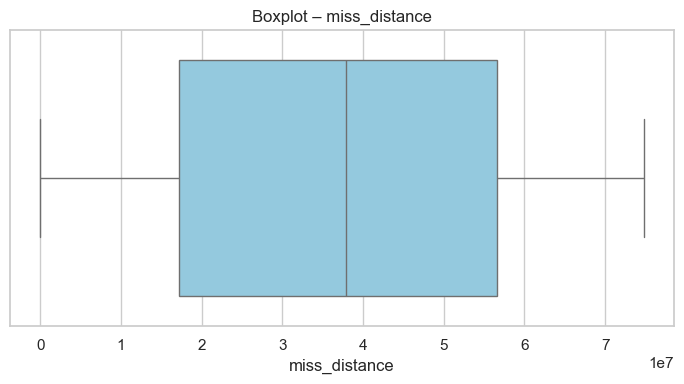

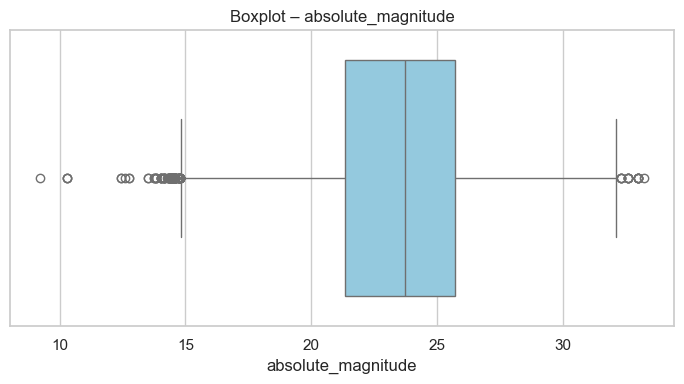

In [14]:
# Boxplot dla każdej kolumny liczbowej
sns.set_theme(style='whitegrid')

# Pobranie kolumn liczbowych
num_cols = df.select_dtypes(include='number').columns

# Rysowanie
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        #x=df[col] if col != 'miss_distance' else df['miss_distance_log'],
        x=df[col],
        color='skyblue'
    )
    
    #plt.title(f"Boxplot – {col}" + (" (log)" if col=='miss_distance' else ''))
    plt.title(f"Boxplot – {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Wnioski:
- est_diameter_min/est_diameter_max: pokazują, że większość asteroid ma zbliżoną, niewielką średnicę; dużych obiektów jest mało, tworzą bardzo długi ogon
- relative_volecity: prędkości mają naturalnie duży zakres; rozkład rozciągnięty; większość danych skupiona na niskich wartościach
- miss_distance: rozkład odległości bardzo duży; zwykły boxplot daje mylące wyniki; większość obiektów przelatuje w relatywnie małej odległości (pierwsze kilka tys. km na histogramie)
- absolute_magnitude: rozkła najbardziej normalny; jedyna zmienna bez ekstremalnej skośności; kilka wartości po lewej stronie (< 15) jasne asteroidy (rzadkie); kilka po prawej (> 30) to ciemniejsze obiekty
- histogramy i boxploty, pokazały że log10 zanacząco poprawi analizę kolumn: est_diameter, relative_velocuity oraz miss_distance, ze względu na występujące rozciągnięcia na duże wartości
- StandardScaler jest niezbędny dla modeli liniowych typu LogisticRegression

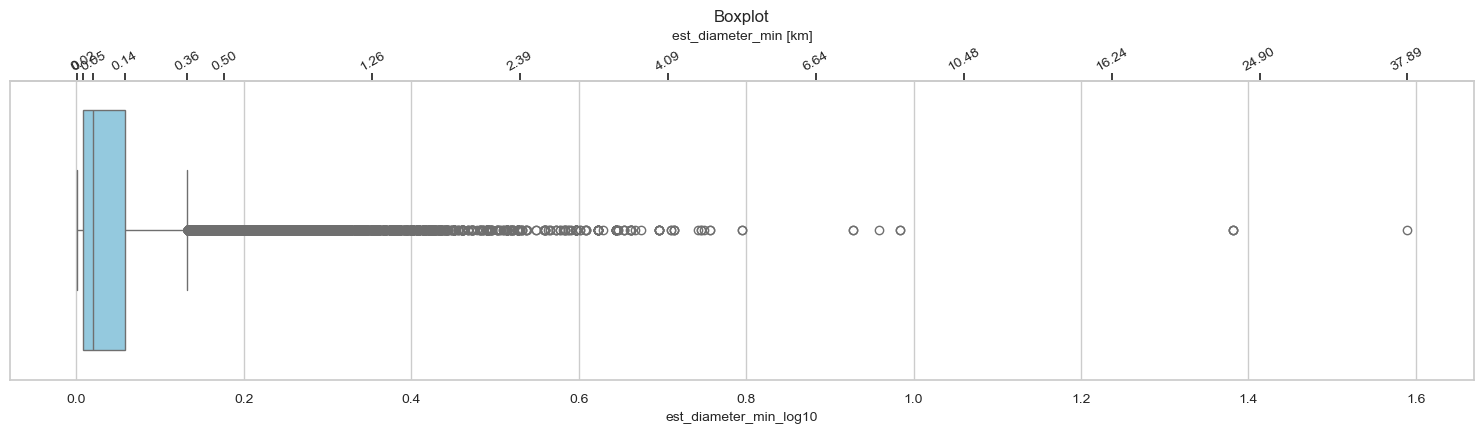

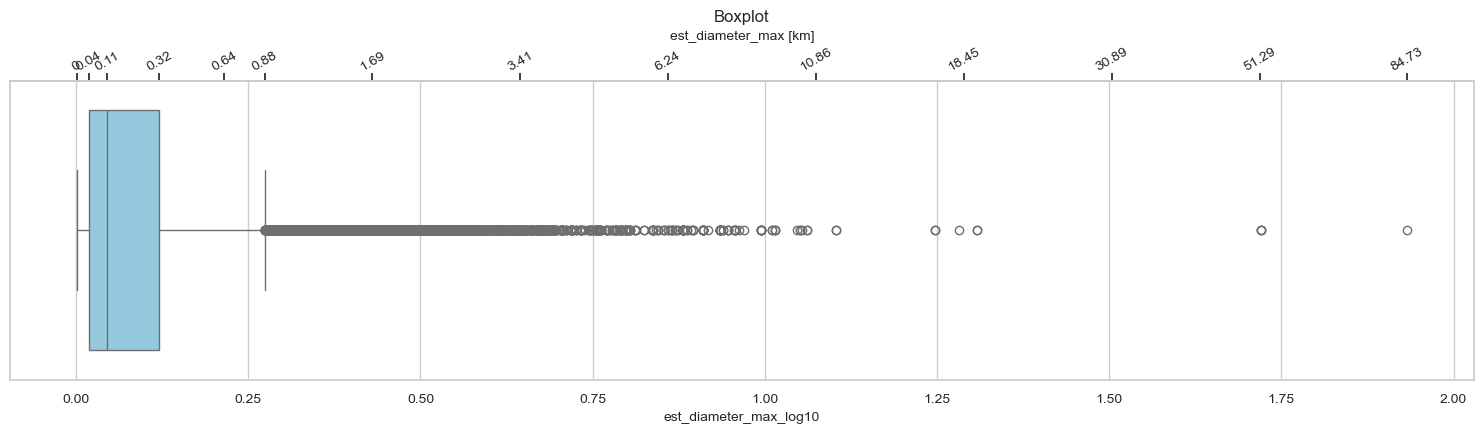

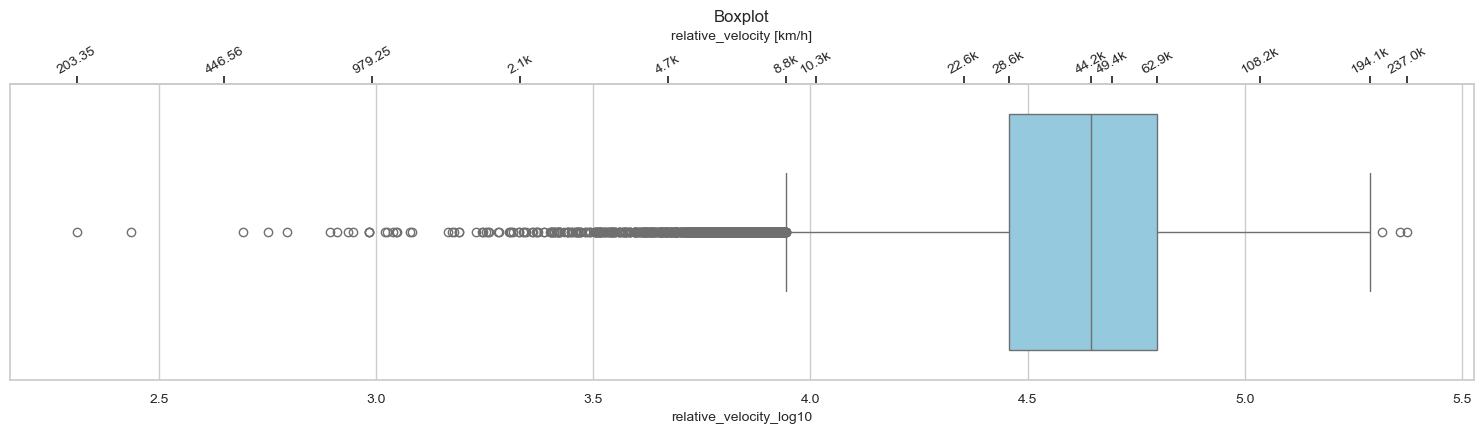

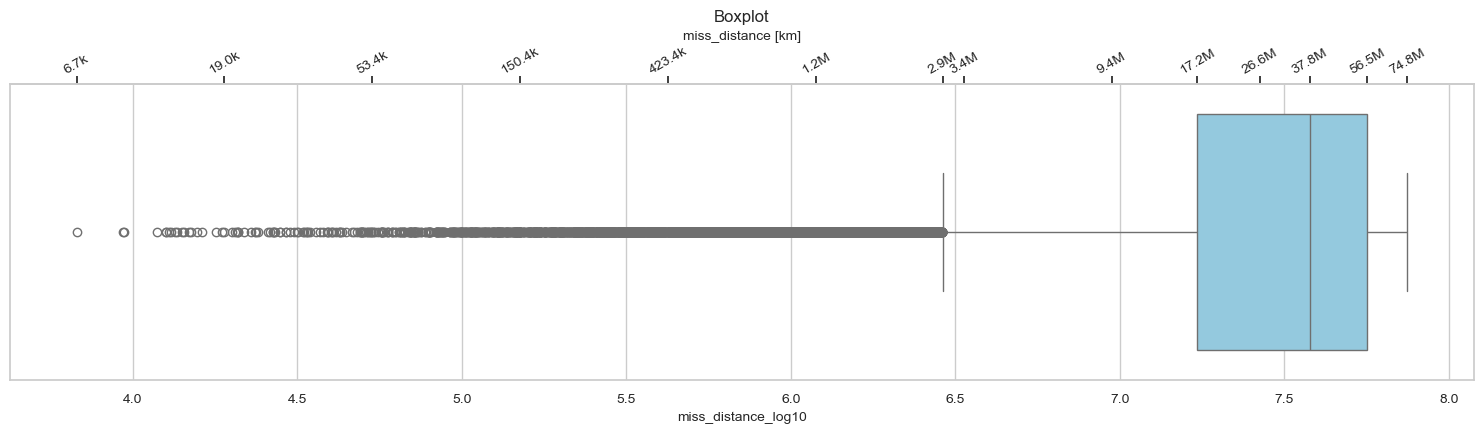

In [15]:
# Tworzymy log10 tam, gdzie wartości są >0 i log-transform ma sens

# Formatowanie liczb
def si_format(x, units=None):
    """
    Format dużych liczb (k/M/B) oraz małych (<1) bez zaokrąglania do zera.
    """
    x = float(x)
    if x == 0:
        s = "0"
    elif x >= 1e9:
        s = f"{x/1e9:.1f}B"
    elif x >= 1e6:
        s = f"{x/1e6:.1f}M"
    elif x >= 1e3:
        s = f"{x/1e3:.1f}k"
    elif x >= 1:
        s = f"{x:.2f}"
    elif x >= 0.01:
        s = f"{x:.2f}"
    #elif x >= 0.001:
    #    s = f"{x:.2f}"
    else:
        #s = f"{x:.2e}"
        s = f"{x:.0f}"
    return f"{s} {units}" if units else s

# Boxplot
def plot_log_box_no_warning(
    df, col, units=None,
    n_ticks=10,            # ile równych ticków na górnej osi
    label_rotation=30,     # obrót etykiet
    label_fontsize=10,     # wielkość czcionki etykiet
    label_pad=0            # odstęp etykiet od osi
):
    # Dane (tylko nieujemne, bo log10(x+1))
    x = pd.to_numeric(df[col], errors='coerce').dropna()
    x = x[x >= 0]
    if x.empty:
        raise ValueError(f"Kolumna '{col}' nie ma nieujemnych wartości.")

    # Dolna oś: log10(x+1) – to na niej rysujemy boxplota
    log_col = f"{col}_log10"
    df[log_col] = np.log10(df[col] + 1)
    #xlog = np.log10(x + 1)

    # Kwantyle w skali oryginalnej
    q1_o, med_o, q3_o = x.quantile([0.25, 0.5, 0.75])

    # Wąsy liczone w przestrzeni log
    q1_l, _, q3_l = np.quantile(df[log_col], [0.25, 0.5, 0.75])
    iqr = q3_l - q1_l

    low_fence  = q1_l - 1.5 * iqr
    high_fence = q3_l + 1.5 * iqr

    inside = df[log_col][(df[log_col] >= low_fence) & (df[log_col] <= high_fence)]
    
    if inside.size > 0:
        lw_l = float(inside.min())   # dolny wąs (log)
        uw_l = float(inside.max())   # górny wąs (log)
    else:
        lw_l = xmin_log
        uw_l = xmax_log

    
    # Wąsy przeliczone na skalę oryginalną
    lw_o = (10**lw_l) - 1
    uw_o = (10**uw_l) - 1


    # Równy podział w przestrzeni log
    xmin_log = float(np.min(df[log_col]))
    xmax_log = float(np.max(df[log_col]))
    ticks_log = np.linspace(xmin_log, xmax_log, n_ticks)  # równomierne w log-space
    ticks_orig = (10**ticks_log) - 1                      # przelicz na oryginalną skalę

    # Dodaj kwantyle jako ticki (w skali oryginalnej)
    all_ticks = list(ticks_orig) + [q1_o, med_o, q3_o] + [lw_o, uw_o]

    # Usuń duplikaty, posortuj
    all_ticks = sorted(set(float(v) for v in all_ticks if v >= 0))

    # RysRysowanie
    _, ax1 = plt.subplots(figsize=(15, 4.5))
    sns.boxplot(x=df[log_col], ax=ax1, color='skyblue')

    ax1.set_title(f"Boxplot")
    ax1.tick_params(axis='x', labelsize=10, rotation=0)
    ax1.set_xlabel(f"{log_col}", fontsize=10)

    # Górna oś (oryginalna skala), mapowania muszą być wzajemnie odwrotne
    ax2 = ax1.secondary_xaxis(
        'top',
        functions=(lambda v: 10**v - 1,        # dolna (log) -> górna (oryginalna)
                   lambda v: np.log10(v + 1))  # górna (oryginalna) -> dolna (log)
    )

    # Ustaw równomierne ticki w oryginalnej skali (górna oś używa własnych jednostek) + kwantyle
    ax2.set_xticks(all_ticks)
    ax2.set_xticklabels([si_format(v) for v in all_ticks],
                        rotation=label_rotation, fontsize=label_fontsize, ha='center')
    ax2.tick_params(axis='x', pad=label_pad)
    ax2.set_xlabel(f"{col}" + (f" [{units}]" if units else ''), fontsize=10)

    plt.tight_layout()
    plt.show()


columns = [
    'est_diameter_min',
    'est_diameter_max',
    'relative_velocity',
    'miss_distance'
]

units = {
    'est_diameter_min': 'km',
    'est_diameter_max': 'km',
    'relative_velocity': 'km/h',
    'miss_distance': 'km'
}

for col in columns:
    plot_log_box_no_warning(df, col, units.get(col, None), n_ticks=10)

Wnioski:
- est_diameter_min/max: log10 bardzo wyraźnie pokazuje, że populacja asteroid jest silnie zdominowana przez małe obiekty; bardzo duże obiekty to pojedyncze przypadki; największe obiekty są rzadkie i zawsze będą outlierami
- relative_velocity: skrajnie wolne i skrajnie szybkie obiekty są fizycznie rzadkie - dlatego są outlierami; po lewej stronie jest widoczna garść wolnych obiektów; po prawej stronie kilka bardzo szybkich obiektów
- miss_distance: widać, że bliskie przeloty to outliery; większość wartości mieści się w przedziale mniej więcej: log10 7.2–7.8 (typowe przeloty); kilka punktów po lewej (log10 3.8–4.5) to ekstremalnie bliskie przeloty - są one rzadkie; większość danych jest skumulowana po prawej stronie

In [16]:
# Czy zbiór jest zbalansowany??
(df['hazardous'].value_counts(normalize=True) * 100).round(0).astype(str) + ' %'

hazardous
False    90.0 %
True     10.0 %
Name: proportion, dtype: object

Wniosek:
- Zbiór jest niezbalansowany: 90% do 10%, że obiekt nie jest niebezpieczny

In [17]:
# Zamiana kolumny 'hazardous' na 0 i 1
df['hazardous'] = df['hazardous'].astype(int)

In [18]:
# Usunięcie kolumn z jedną wartością uniklaną
cols_single_value = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
df = df.drop(columns=cols_single_value)

# Usunięcie kolumn object
cols_obj = object_cols = df.select_dtypes(include='object').columns.tolist()
df = df.drop(columns=cols_obj)

# Usunięcie kolumn podobnych cechami
cols_est_min = ['est_diameter_min', 'est_diameter_min_log10']
df = df.drop(columns=cols_est_min)

In [19]:
df.dtypes

est_diameter_max           float64
relative_velocity          float64
miss_distance              float64
absolute_magnitude         float64
hazardous                    int32
est_diameter_max_log10     float64
relative_velocity_log10    float64
miss_distance_log10        float64
dtype: object

In [20]:
df

,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous,est_diameter_max_log10,relative_velocity_log10,miss_distance_log10
0,2.679415,13569.249224,5.483974e+07,16.73,0,0.565779,4.132588,7.739095
1,0.594347,73588.726663,6.143813e+07,20.00,1,0.202583,4.866817,7.788438
2,1.614507,114258.692129,4.979872e+07,17.83,0,0.417390,5.057893,7.697218
3,0.215794,24764.303138,2.543497e+07,22.20,0,0.084860,4.393844,7.405431
4,0.570217,42737.733765,4.627557e+07,20.09,1,0.195960,4.630822,7.665352
...,...,...,...,...,...,...,...,...
90831,0.059435,52078.886692,1.230039e+07,25.00,0,0.025074,4.716670,7.089919
90832,0.037501,46114.605073,5.432121e+07,26.00,0,0.015988,4.663848,7.734969
90833,0.071456,7566.807732,2.840077e+07,24.60,0,0.029974,3.878970,7.453330
90834,0.016370,69199.154484,6.869206e+07,27.80,0,0.007052,4.840107,7.836907


## Modelowanie

In [21]:
# Kopia oczyszczonego zbioru
data = df.copy()

In [22]:
# Cechy i cel
X = data.drop(columns=['hazardous'], axis=1)
y = data['hazardous']

In [23]:
# Podział na zbór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Zbiór treningowy: {X_train.shape[0]}")
print(f"Zbiór testowy: {X_test.shape[0]}")

Zbiór treningowy: 72668
Zbiór testowy: 18168


In [24]:
# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-0.33161593 -0.18816043  0.49429671 ... -0.59303536  0.07882534
   0.55705311]
 [-0.31248614 -1.04072901  0.86671592 ... -0.54430178 -1.10549439
   0.69725673]
 [ 0.23424598  2.42713352  1.21939932 ...  0.63831598  1.67427716
   0.81213706]
 ...
 [-0.3781594  -0.54688369  0.24539966 ... -0.7142438  -0.32544868
   0.44909856]
 [ 0.29629984 -1.12836857 -0.69613044 ...  0.75221082 -1.2901484
  -0.15025919]
 [ 0.54240391 -1.09858993 -0.86744013 ...  1.17343745 -1.22516037
  -0.32241488]]
[[ 1.09884108 -1.04039457 -0.11903108 ...  1.98411532 -1.10482632
   0.26242625]
 [-0.14081804  0.20725751  1.41065335 ... -0.13251941  0.43622683
   0.86867717]
 [-0.35082256 -0.19667109 -0.49941169 ... -0.64259233  0.07025527
   0.01310783]
 ...
 [-0.38664265 -1.60114275 -1.37399479 ... -0.73675236 -2.91415941
  -1.21982519]
 [-0.14081804 -1.03582878  0.90712867 ... -0.13251941 -1.09573169
   0.71120812]
 [-0.28638702  0.07016984  0.2668182  ... -0.47879183  0.32053013
   0.45892788]]


In [25]:
# Budowanie modelu LogisticRegression
model_lg = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs', class_weight='balanced', max_iter=800
)
model_lg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,800
,multi_class,'deprecated'


In [26]:
# Predyckcja - wybieramy tylko, te obiekty, gdzie prawdopodobieństwo klasy jest 1 oraz predykcję równą 1, gdzie proba jest >=0.5
proba_lg = model_lg.predict_proba(X_test_scaled)[:, 1]
pred_lg = (proba_lg >= 0.5).astype(int)

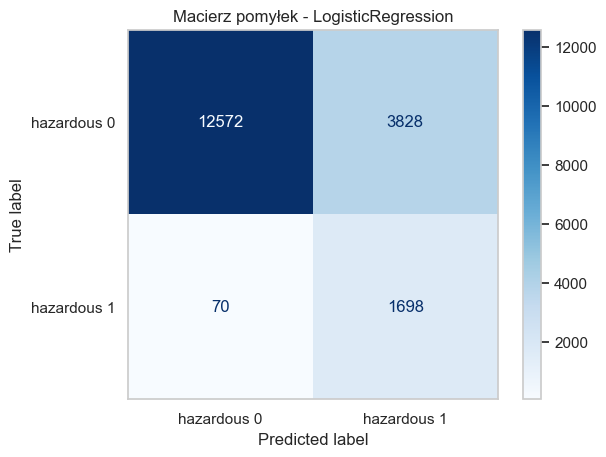

array([[12572,  3828],
       [   70,  1698]], dtype=int64)

In [27]:
# Macierz pomyłek
cm_lg = confusion_matrix(y_test, pred_lg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lg, display_labels=['hazardous 0', 'hazardous 1'])
disp.plot(cmap='Blues')  # Możesz zmienić schemat kolorów
disp.ax_.grid(False)

plt.title("Macierz pomyłek - LogisticRegression")
#plt.ylabel("Actual values")
#plt.xlabel("Predicted Values")
plt.show()

cm_lg

In [28]:
# metryki
accuracy_lg = accuracy_score(y_test, pred_lg)
print(f"Dokładność modelu - LogisticRegression: {accuracy_lg:.2f}")

print("\nRaport klasyfikacji - LogisticRegression:")
print(classification_report(y_test, pred_lg))

Dokładność modelu - LogisticRegression: 0.79

Raport klasyfikacji - LogisticRegression:
              precision    recall  f1-score   support

           0       0.99      0.77      0.87     16400
           1       0.31      0.96      0.47      1768

    accuracy                           0.79     18168
   macro avg       0.65      0.86      0.67     18168
weighted avg       0.93      0.79      0.83     18168



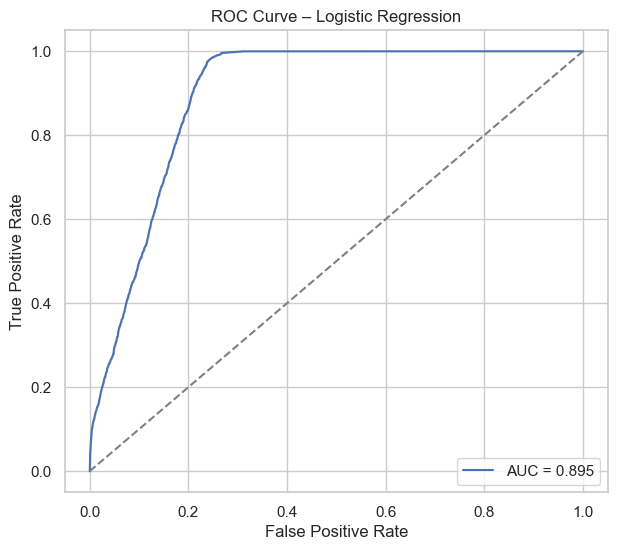

In [29]:
# Wykres krzywej ROC
sns.set_theme(style='whitegrid')

fpr, tpr, _ = roc_curve(y_test, proba_lg)
roc_auc = roc_auc_score(y_test, proba_lg)

plt.figure(figsize=(7, 6))
sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.3f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

Wniosek:
- Model bardzo dobrze wykrywa obiekty groźne (TP = 1698). To oznacza wysoką czułość (recall) i małą liczbę przegapionych zagrożeń
- Bardzo mało przegapionych groźnych obiektów (FN = 70). Model rzadko myli obiekt groźny z niegroźnym
- Duża liczba fałszywych alarmów (FP = 3828). Często przewiduje klasę "hazardous", nawet gdy obiekt w rzeczywistości nie jest groźny. Skutkuje to:
niską precyzją, większą liczbą fałszywych ostrzeżeń. Model jest "nadwrażliwy" - reaguje za często
- Poprawne rozpoznanie obiektów niegroźnych na dobrym poziomie (TN = 12572)
- Wysoki recall = 96% - wykrywa groźne obiekty bardzo skutecznie. Niskie Precision = 31% - model daje fałszywy alarm
- Model w 89.5% przypadków nada wyższe prawdopodobieństwo bycia "hazardous", temu obiektowi, który faktycznie jest groźny (AUC ROC = 0,895).

In [30]:
print(f"Zbiór treningowy: {X_train.shape[0]}")
print(f"Zbiór testowy: {X_test.shape[0]}")

Zbiór treningowy: 72668
Zbiór testowy: 18168


In [31]:
# Budowanie modelu XGBoost
#model_xgb = XGBClassifier(
#    n_estimators=500,
#    max_depth=5,
#    learning_rate=0.05,
#    subsample=0.9,
#    colsample_bytree=0.8,
#    eval_metric='logloss',
#    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])  # dla balansu klas
#)
#
#model_xgb.fit(X_train, y_train)

In [32]:
# Budowanie modelu XGBoost
model_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    #use_label_encoder=False,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),  # dla balansu klas
    tree_method='hist',
    random_state=42,
    n_jobs=1
)

# Siatka parametrów
param_dist = {
    'max_depth': np.arange(2, 9),
    'n_estimators': np.arange(100, 700, 50),
    'learning_rate': np.linspace(0.01, 0.15, 15),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'min_child_weight': np.arange(1, 10),
    'gamma': np.linspace(0, 1.0, 6),
    'reg_lambda': np.linspace(0, 8, 10),
    'reg_alpha': np.linspace(0, 2, 10)
}

# Cross-validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearchCV
model_xgbrscv = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_dist,
    n_iter=24,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    verbose=2,
    n_jobs=1         
)

In [33]:
# Trening
model_xgbrscv.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END colsample_bytree=0.7, gamma=0.8, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.0, reg_lambda=6.222222222222221, subsample=0.7; total time=   0.7s
[CV] END colsample_bytree=0.7, gamma=0.8, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.0, reg_lambda=6.222222222222221, subsample=0.7; total time=   0.7s
[CV] END colsample_bytree=0.7, gamma=0.8, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.0, reg_lambda=6.222222222222221, subsample=0.7; total time=   0.8s
[CV] END colsample_bytree=0.9, gamma=0.8, learning_rate=0.07999999999999999, max_depth=4, min_child_weight=5, n_estimators=450, reg_alpha=1.5555555555555554, reg_lambda=1.7777777777777777, subsample=0.9; total time=   1.7s
[CV] END colsample_bytree=0.9, gamma=0.8, learning_rate=0.07999999999999999, max_depth=4, min_child_weight=5, n_estimators=450, reg_alpha=1.

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': array([0.6, 0....8, 0.9, 1. ]), 'gamma': array([0. , 0....6, 0.8, 1. ]), 'learning_rate': array([0.01, ..., 0.14, 0.15]), 'max_depth': array([2, 3, 4, 5, 6, 7, 8]), ...}"
,n_iter,24
,scoring,'roc_auc'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [34]:
print("\n=== Najlepsze parametry ===")
print(model_xgbrscv.best_params_)
print(f"Najlepszy ROC AUC (CV): {model_xgbrscv.best_score_:.3f}")


=== Najlepsze parametry ===
{'subsample': 0.9, 'reg_lambda': 0.8888888888888888, 'reg_alpha': 0.2222222222222222, 'n_estimators': 450, 'min_child_weight': 6, 'max_depth': 7, 'learning_rate': 0.05999999999999999, 'gamma': 0.8, 'colsample_bytree': 1.0}
Najlepszy ROC AUC (CV): 0.921


In [35]:
# Najlepszy model
best_xgb = model_xgbrscv.best_estimator_
best_xgb

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [36]:
# Predyckcja - wybieramy tylko, te obiekty, gdzie prawdopodobieństwo klasy jest 1 oraz predykcję równą 1, gdzie proba jest >=0.5
proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

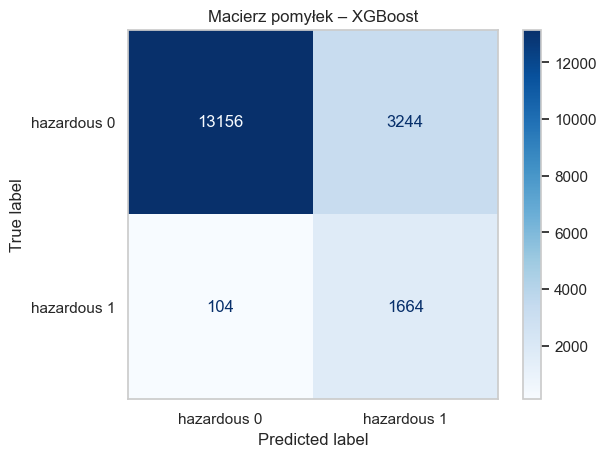

array([[13156,  3244],
       [  104,  1664]], dtype=int64)

In [37]:
# Macierz pomyłek
cm_xgb = confusion_matrix(y_test, pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['hazardous 0', 'hazardous 1'])
disp.plot(cmap='Blues')
disp.ax_.grid(False)

plt.title("Macierz pomyłek – XGBoost")
plt.show()

cm_xgb

In [38]:
# Metryki
accuracy_xgb = accuracy_score(y_test, pred_xgb)
print(f"Dokładność modelu XGBoost: {accuracy_xgb:.2f}")

print("\nRaport klasyfikacji – XGBoost:")
print(classification_report(y_test, pred_xgb))

Dokładność modelu XGBoost: 0.82

Raport klasyfikacji – XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.80      0.89     16400
           1       0.34      0.94      0.50      1768

    accuracy                           0.82     18168
   macro avg       0.67      0.87      0.69     18168
weighted avg       0.93      0.82      0.85     18168



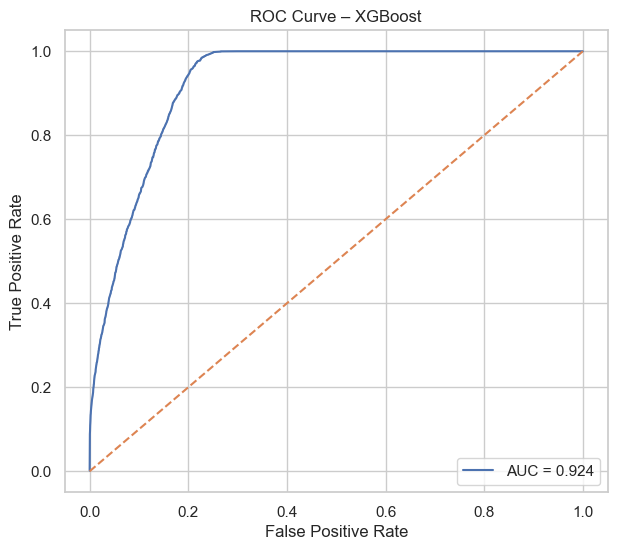

In [39]:
# ROC
fpr, tpr, _ = roc_curve(y_test, proba_xgb)
roc_auc = roc_auc_score(y_test, proba_xgb)

plt.figure(figsize=(7, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.3f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.grid(True)
plt.show()

Wnioski:
- Model bardzo dobrze rozpoznaje obiekty niegroźne (TN = 13156). Świadczy to o dobrej zdolności do wykrywania danych negatywnych
- W stosunku do LogisticRegression zmniejszył o 15% liczbę fałszywych alarmów (FP = 3244). Poprawia to wiarygodność modelu
- Model trafnie identyfikuje dużą większość obiektów rzeczywiście groźnych (TP = 1664)
- Niewiele przegapionych obiektów groźnych (FN = 104). Pomimo tego, że XGBoost jest trochę bardziej ostrożny niż LogisticRegression - ma nieco więcej FN, to nadal utrzymuje bardzo wysoki poziom wykrywalności
- XGBoost zwiększył precision, czyli redukuje liczbę fałszywych alarmów. Minimalnie obniżył recall, ale zachowuje go na bardzo wysokim poziomie (ok. 94%)
- XGBoost przewyższa LogisticRegression w jakości predykcji (AUC ROC = 0,924)

Wniosek ogólny:
- Model XGBoost osiągnął wyższy ROC AUC (0,924) niż Logistic Regression (0,895), co oznacza, że lepiej odróżnia obiekty groźne od niegroźnych, jest bardziej stabilny przy różnych progach decyzyjnych i tworzy bardziej wiarygodny ranking ryzyka. XGBoost zapewnia wyraźnie lepszą jakość predykcji.